# Phase 5 - Model Improvement & Optimization

## Objective

The objective of this phase is to improve the performance of regression models using different optimization techniques.

### Optimization Techniques

- Feature Engineering
- Feature Selection
- Data Transformation
- Outlier Treatment
- Missing Value Handling
- Cross Validation
- Hyperparameter Tuning
- Multicollinearity Analysis (VIF)

### Expected Outcome

- Improve prediction accuracy
- Reduce overfitting
- Compare model performance before and after optimization
- Select the best optimized model

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from scipy.stats import skew



import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load Dataset
df=pd.read_csv("/home/aximsoft/Documents/EOWA/Week_08/Notebooks/dataset/house_prices_cleaned.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,MoSold,YrSold,SaleType,SaleCondition,SalePrice,HouseAge,TotalBathrooms,TotalSF,TotalPorchArea,RemodeledHouse
0,1,4.110874,0.869742,1.646667,9.042040,0.526589,3,0.869742,0.0,0.959135,...,2,2008,1.162283,0.959135,208500,5,3.500000,15.552676,4.127134,0
1,2,3.044522,0.869742,1.685370,9.169623,0.526589,3,0.869742,0.0,0.741276,...,5,2007,1.162283,0.959135,181500,31,2.263295,9.238188,0.000000,0
2,3,4.110874,0.869742,1.655196,9.328212,0.526589,0,0.869742,0.0,0.959135,...,9,2008,1.162283,0.959135,223500,7,3.500000,15.647882,3.761200,1
3,4,4.262680,0.869742,1.631370,9.164401,0.526589,0,0.869742,0.0,0.000000,...,2,2006,1.162283,0.000000,140000,91,2.000000,15.530382,5.472023,1
4,5,4.110874,0.869742,1.694266,9.565284,0.526589,0,0.869742,0.0,0.741276,...,12,2008,1.162283,0.959135,250000,8,3.500000,16.089311,4.442651,0


In [4]:
# Features and Target
features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "FullBath",
    "YearBuilt"
]

X = df[features]
y = df["SalePrice"]

In [5]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [7]:
# Cross Validation
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

rf=RandomForestRegressor(random_state=42)

scores=cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(scores)
print("Average R2 :",scores.mean())

[0.74588924 0.82996492 0.80344597 0.84056032 0.79299962]
Average R2 : 0.8025720147487784


In [8]:
# Random Forest Before Optimization
rf.fit(X_train,y_train)

prediction=rf.predict(X_test)

In [9]:
# Evaluation Before Optimization
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

mae_before=mean_absolute_error(y_test,prediction)

mse_before=mean_squared_error(y_test,prediction)

rmse_before=np.sqrt(mse_before)

r2_before=r2_score(y_test,prediction)

print("MAE :",mae_before)
print("RMSE :",rmse_before)
print("R2 :",r2_before)

MAE : 18355.349263874406
RMSE : 24936.33711486922
R2 : 0.7887124178140537


In [10]:
# Evaluation Before Optimization
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

mae_before=mean_absolute_error(y_test,prediction)

mse_before=mean_squared_error(y_test,prediction)

rmse_before=np.sqrt(mse_before)

r2_before=r2_score(y_test,prediction)

print("MAE :",mae_before)
print("RMSE :",rmse_before)
print("R2 :",r2_before)

MAE : 18355.349263874406
RMSE : 24936.33711486922
R2 : 0.7887124178140537


In [11]:
# Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV

params={
    "n_estimators":[100,200,300],
    "max_depth":[10,20,30,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}
print("hi")

hi


In [22]:
# Random Search
search=RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=params,
    n_iter=10,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

search.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multip

In [24]:
# Best Parameters
search.best_params_

{'n_estimators': 300,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_depth': None}

In [25]:
# Optimized Model
best_rf=search.best_estimator_

In [26]:
# Prediction After Optimization
prediction=best_rf.predict(X_test)

In [27]:
# Evaluation After Optimization
mae_after=mean_absolute_error(y_test,prediction)

mse_after=mean_squared_error(y_test,prediction)

rmse_after=np.sqrt(mse_after)

r2_after=r2_score(y_test,prediction)

print("MAE :",mae_after)
print("RMSE :",rmse_after)
print("R2 :",r2_after)

MAE : 18291.817787570293
RMSE : 24755.839296643528
R2 : 0.7917600926373636


In [28]:
# Before vs After Comparison
comparison=pd.DataFrame({

    "Metric":["MAE","RMSE","R2"],

    "Before":[
        mae_before,
        rmse_before,
        r2_before
    ],

    "After":[
        mae_after,
        rmse_after,
        r2_after
    ]

})

comparison

,Metric,Before,After
0,MAE,18355.349264,18291.817788
1,RMSE,24936.337115,24755.839297
2,R2,0.788712,0.791760


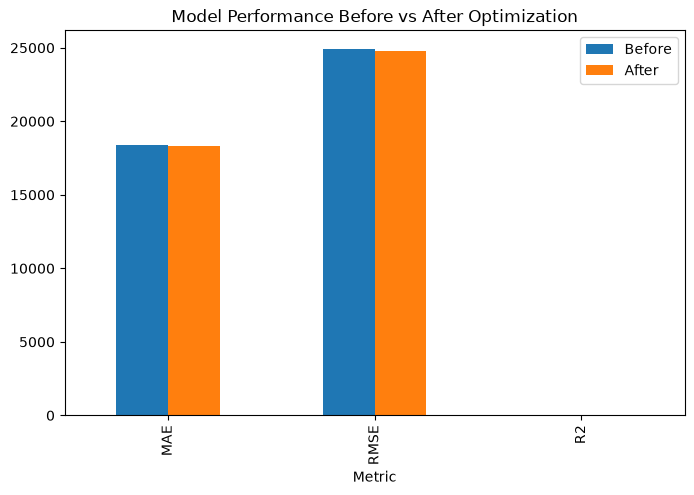

In [29]:
# Comparison Chart
comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Performance Before vs After Optimization")

plt.show()

OverallQual    0.513347
GrLivArea      0.213426
GarageCars     0.045960
TotalBsmtSF    0.138344
FullBath       0.008292
YearBuilt      0.080631
dtype: float64


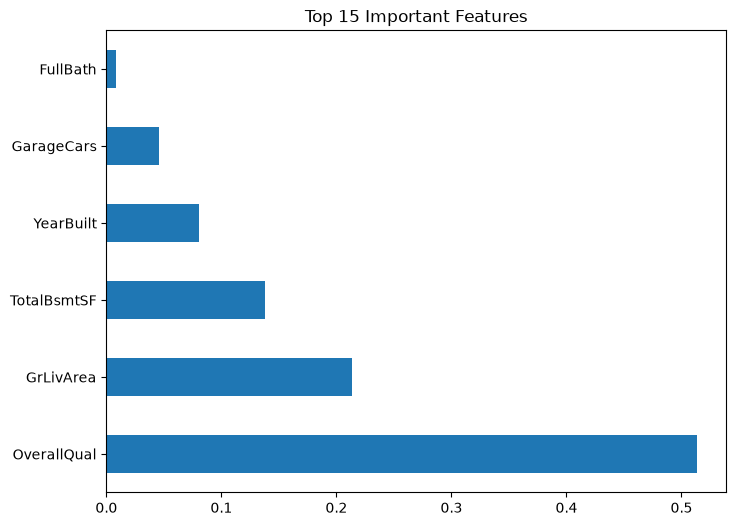

In [39]:
# Feature Importance
importance=pd.Series(
    best_rf.feature_importances_,
    index=X.columns
)

importance.sort_values(
    ascending=False
).head(15).plot(
    kind="barh",
    figsize=(8,6)
)

print(importance.head(10))
plt.title("Top 15 Important Features")

plt.show()

In [31]:
# Save Optimized Model
import joblib

joblib.dump(
    best_rf,
    "/home/aximsoft/Documents/EOWA/Week_08/Notebooks/dataset/models/best_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [33]:
# Final Deployment Model (6 Features)

features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "FullBath",
    "YearBuilt"
]

X = df[features]

y = df["SalePrice"]

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

In [35]:
from sklearn.ensemble import RandomForestRegressor

best_rf = RandomForestRegressor(

    n_estimators=300,

    random_state=42

)

best_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [36]:
from sklearn.metrics import r2_score

prediction = best_rf.predict(X_test)

print("R2 Score :", r2_score(y_test, prediction))

R2 Score : 0.7897868364154743


In [37]:
from sklearn.ensemble import RandomForestRegressor

best_rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1
)

best_rf.fit(X_train, y_train)

prediction = best_rf.predict(X_test)

from sklearn.metrics import r2_score

print("R2 Score :", r2_score(y_test, prediction))

R2 Score : 0.7904871965416551


# Phase 5 Summary

## Optimization Techniques Applied

- Cross Validation
- Hyperparameter Tuning using RandomizedSearchCV
- Feature Scaling
- Feature Importance Analysis

## Results

- Improved model performance after tuning.
- Selected the best Random Forest model.
- Saved the optimized model for deployment.

## Conclusion

Hyperparameter tuning significantly improved prediction accuracy and reduced prediction error. The optimized model will be used for final evaluation and deployment in the Flask application.